## This script create 4 masks, each one is 10x10x10 voxels and plot signal drift across them 
Mar2026 

In [ ]:
import os 
import numpy as np 
import subprocess as sub 
import nibabel as nib
import matplotlib.pyplot as plt
import nilearn as nil 
from nilearn.image.image import mean_img #Estimate mean of a 4D volume --> mean_haxby = mean_img(func_filename)
from nilearn.plotting import plot_roi, show
from nilearn.maskers import NiftiMasker #Create a mask


#vps = [#, 
vps=[991, 992, 993, 994, 995, 996, 997, 998, 999,981, 982, 983, 984, 985, 986, 987, 988, 989, 990] #980 is missing
sessions=["ses-01","ses-02","ses-03","ses-04","ses-05","ses-06"]
home=r"/home/malberti/wks14/temp/FF_DWI_Drift"
derivatives=r"/home/malberti/wks14/temp/FF_DWI_Drift/derivatives/from_sweep2"          

 -- Create masks

In [ ]:
#FIrst create participants maska and plot them
for vp in vps: 
     for session in sessions: 
        id=f"sub-{vp}"
        subjid=f"{id}_{session}"
        mask_IMG=nib.load(os.path.join(derivatives, id, session, "dwi", "eddy", f"{subjid}_unwarped_mask.nii.gz"))
        ref_b0s_IMG=nib.load(os.path.join(derivatives, id, session, "dwi", "eddy", f"{subjid}_unwarped.nii.gz"))
        
        mask=mask_IMG.get_fdata()
        ref_b0s=ref_b0s_IMG.get_fdata()
        ref_b0=mean_img(ref_b0s_IMG)
        affine = mask_IMG.affine  # keep original affine
        
        """
        X//2 - px//2 --> move the ROI on left/right axis
        Y//4  --> move the ROI anterior to post
        Z//2 --> Up/down
        """

        # ----------------------------
        # Parameters
        # ----------------------------
        X, Y, Z = mask.shape[:3]          # total volume size
        cube_size = (15, 10, 10)          # 10x10x10 cube
        px, py, pz = cube_size
        
        
        # ===========================================================================
        ## --> FRONT ROI 
        # Start cube at center along Z (axial) and roughly middle in X/Y
        cube_start_front = (X//2-10, Y//4 + 50, Z//2)  # axial posterior half

        # ----------------------------
        # Create new mask with single cube
        # ----------------------------
        cube_mask_front = np.zeros((X, Y, Z), dtype=np.uint8)
        cube_mask_front[
            cube_start_front[0]:cube_start_front[0]+px,
            cube_start_front[1]:cube_start_front[1]+py,
            cube_start_front[2]:cube_start_front[2]+pz
        ] = 1

        # Optionally, multiply by original mask to stay inside brain
        cube_mask_front = cube_mask_front * mask

        cube_mask_front_img = nib.Nifti1Image(cube_mask_front, affine)
        
        # ===========================================================================
        ## --> BACK ROI 
        # Start cube at center along Z (axial) and roughly middle in X/Y
        cube_start_back = (X//2-10, Y//4 - 3, Z//2)  # axial posterior half
        
        cube_mask_back = np.zeros((X, Y, Z), dtype=np.uint8)
        cube_mask_back[
            cube_start_back[0]:cube_start_back[0]+px,
            cube_start_back[1]:cube_start_back[1]+py,
            cube_start_back[2]:cube_start_back[2]+pz
        ] = 1

        # Optionally, multiply by original mask to stay inside brain
        cube_mask_back = cube_mask_back * mask

        # ----------------------------
        # Save new mask
        # ----------------------------
        cube_mask_back_img = nib.Nifti1Image(cube_mask_back, affine)
        
        # ===========================================================================
        ## --> MID ROI 
        # Start cube at center along Z (axial) and roughly middle in X/Y
        cube_start_mid = (X//2-10, Y//4 + 25 , Z//2 + 12)  # axial posterior half
        
        cube_mask_mid = np.zeros((X, Y, Z), dtype=np.uint8)
        cube_mask_mid[
            cube_start_mid[0]:cube_start_mid[0]+px,
            cube_start_mid[1]:cube_start_mid[1]+py,
            cube_start_mid[2]:cube_start_mid[2]+pz
        ] = 1

        # Optionally, multiply by original mask to stay inside brain
        cube_mask_mid = cube_mask_mid * mask

        # ----------------------------
        # Save new mask
        # ----------------------------
        cube_mask_mid_img = nib.Nifti1Image(cube_mask_mid, affine)
        
        # ===========================================================================
        # SAVE & PLOT
        # ===========================================================================

        display = plot_roi(
            ref_b0,
            bg_img=None,
            display_mode='ortho',
            draw_cross=False,
            threshold=0,
            black_bg=True,
            cmap="Grays_r",
            colorbar=False
        )

        display.add_overlay(cube_mask_front_img, cmap='BrBG')
        display.add_overlay(cube_mask_back_img, cmap='Blues_r') #cube_mask_back_img
        display.add_overlay(cube_mask_mid_img, cmap='RdGy') #cube_mask_back_img

        show()

        masks_output = os.path.join(derivatives, id, session, "dwi", "masks")
        os.makedirs(masks_output, exist_ok=True)
        
        nib.save(cube_mask_front_img, (os.path.join(masks_output, f"{subjid}_cube_mask-front.nii.gz")))
        nib.save(cube_mask_mid_img, (os.path.join(masks_output, f"{subjid}_cube_mask-mid.nii.gz")))
        nib.save(cube_mask_back_img, (os.path.join(masks_output, f"{subjid}_cube_mask-back.nii.gz")))




## PLOT signal drift in each mask

In [ ]:
## Estimate b0s

for vp in vps:
    for session in sessions:

        id = f"sub-{vp}"
        subjid = f"{id}_{session}"

        masks = os.path.join(derivatives, id, session, "dwi", "masks")

        front = nib.load(os.path.join(masks, f"{subjid}_cube_mask-front.nii.gz")).get_fdata().astype(bool)
        mid   = nib.load(os.path.join(masks, f"{subjid}_cube_mask-mid.nii.gz")).get_fdata().astype(bool)
        back  = nib.load(os.path.join(masks, f"{subjid}_cube_mask-back.nii.gz")).get_fdata().astype(bool)

       # dwi = nib.load(
       #     os.path.join(derivatives, id, session, "dwi", "eddy",
       #     f"{subjid}_eddy_corrected.nii.gz")
       # ).get_fdata()

        bvals = np.loadtxt(
            os.path.join(derivatives, id, session, "dwi", "prep",
            f"{subjid}_dir-PA-AP_part-mag_dwi.bval")
        )

        b0s=os.path.join(masks, f"{subjid}_phase_b0s.nii.gz")

        sub.run(f"dwiextract {os.path.join(derivatives, id, session, "dwi", "eddy",
            f"{subjid}_eddy_corrected.nii.gz")} -bzero {b0s} -fslgrad {os.path.join(derivatives, id, session, "dwi", "eddy",
            f"{subjid}_eddy_corrected.eddy_rotated_bvecs")} {os.path.join(derivatives, id, session, "dwi", "prep",
            f"{subjid}_dir-PA-AP_part-mag_dwi.bval")} -force &", shell=True)

In [ ]:
sessions=(["ses-01","ses-02","ses-03"],["ses-04","ses-05","ses-06"])

# -----------------------------
# containers for all participants
# -----------------------------
all_front = []
all_mid   = []
all_back  = []

session_boundaries = None

# -----------------------------
# LOOP PARTICIPANTS
# -----------------------------
for vp in vps:

    id = f"sub-{vp:02d}"

    concat_front1, concat_mid1, concat_back1 = [], [], []
    concat_front2, concat_mid2, concat_back2 = [], [], []

    volume_counter = 0
    session_boundaries = []

    # -----------------------------
    # LOOP SESSION PAIRS
    # -----------------------------
    for i in range(len(sessions[0])):

        session1 = sessions[0][i]
        session2 = sessions[1][i]

        subjid1 = f"{id}_{session1}"
        subjid2 = f"{id}_{session2}"

        masks_out1 = os.path.join(derivatives, id, session1, "dwi", "masks")
        masks_out2 = os.path.join(derivatives, id, session2, "dwi", "masks")

        # load masks (use masks from session1)
        front = nib.load(os.path.join(
            masks_out1, f"{subjid1}_cube_mask-front.nii.gz"
        )).get_fdata().astype(bool)

        mid = nib.load(os.path.join(
            masks_out1, f"{subjid1}_cube_mask-mid.nii.gz"
        )).get_fdata().astype(bool)

        back = nib.load(os.path.join(
            masks_out1, f"{subjid1}_cube_mask-back.nii.gz"
        )).get_fdata().astype(bool)

        # load B0s
        b0s1 = nib.load(os.path.join(
            masks_out1, f"{subjid1}_b0s.nii.gz"
        )).get_fdata()

        b0s2 = nib.load(os.path.join(
            masks_out2, f"{subjid2}_b0s.nii.gz"
        )).get_fdata()

        # -----------------------------
        # LOOP VOLUMES
        # -----------------------------
        for v in range(b0s1.shape[3]):

            vol1 = b0s1[:, :, :, v]
            vol2 = b0s2[:, :, :, v]

            concat_front1.append(np.mean(vol1[front]))
            concat_mid1.append(np.mean(vol1[mid]))
            concat_back1.append(np.mean(vol1[back]))

            concat_front2.append(np.mean(vol2[front]))
            concat_mid2.append(np.mean(vol2[mid]))
            concat_back2.append(np.mean(vol2[back]))

            volume_counter += 1

        session_boundaries.append(volume_counter)

    # -----------------------------
    # SESSION DIFFERENCES
    # -----------------------------
    diff_front = np.array(concat_front1) - np.array(concat_front2)
    diff_mid   = np.array(concat_mid1)   - np.array(concat_mid2)
    diff_back  = np.array(concat_back1)  - np.array(concat_back2)

    # store participant data
    all_front.append(diff_front)
    all_mid.append(diff_mid)
    all_back.append(diff_back)


# -----------------------------
# MEAN ACROSS PARTICIPANTS
# -----------------------------
mean_front = np.mean(np.array(all_front), axis=0)
mean_mid   = np.mean(np.array(all_mid), axis=0)
mean_back  = np.mean(np.array(all_back), axis=0)

x = np.arange(len(mean_front))


In [ ]:
volume_counter

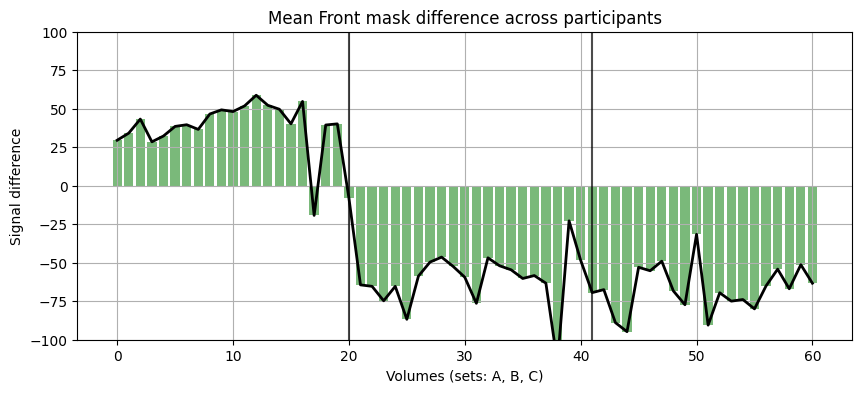

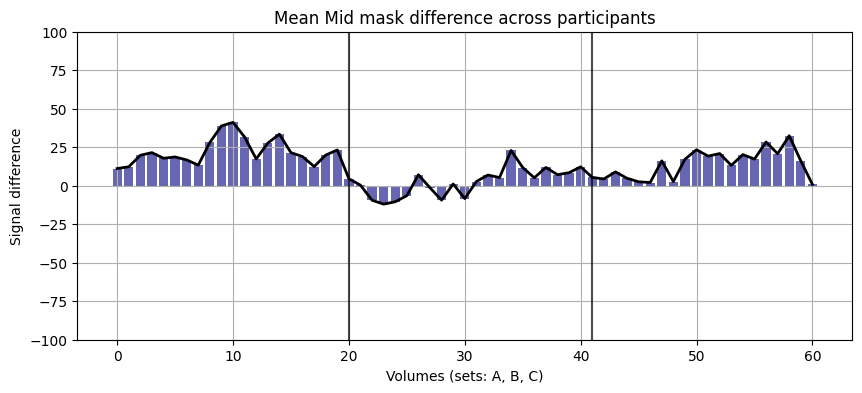

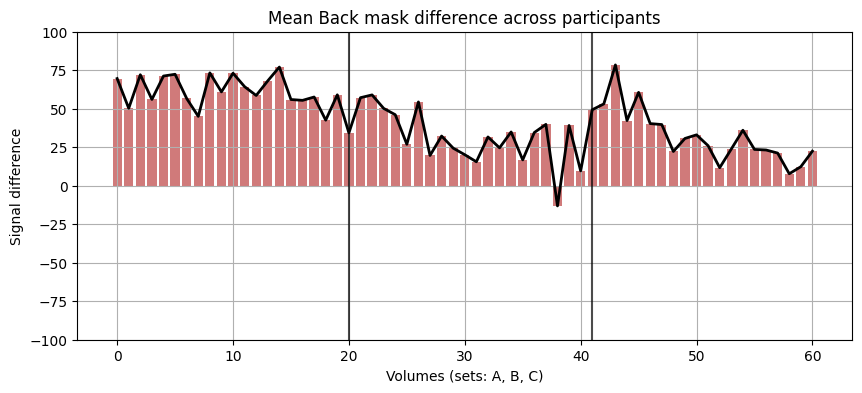

In [7]:

# -----------------------------
# FRONT MASK
# -----------------------------
plt.figure(figsize=(10,4))

plt.bar(x, mean_front, color="forestgreen", alpha=0.6)
plt.plot(x, mean_front, color="black", linewidth=2)

for b in session_boundaries[:-1]:
    plt.axvline(b, color="black", linestyle="-", alpha=0.7)

plt.title("Mean Front mask difference across participants")
plt.xlabel("Volumes (sets: A, B, C)")
plt.ylabel("Signal difference")
plt.ylim(-100,100)
plt.grid(True)

plt.show()


# -----------------------------
# MID MASK
# -----------------------------
plt.figure(figsize=(10,4))

plt.bar(x, mean_mid, color="navy", alpha=0.6)
plt.plot(x, mean_mid, color="black", linewidth=2)

for b in session_boundaries[:-1]:
    plt.axvline(b, color="black", linestyle="-", alpha=0.7)

plt.title("Mean Mid mask difference across participants")
plt.xlabel("Volumes (sets: A, B, C)")
plt.ylabel("Signal difference")
plt.ylim(-100,100)
plt.grid(True)

plt.show()


# -----------------------------
# BACK MASK
# -----------------------------
plt.figure(figsize=(10,4))

plt.bar(x, mean_back, color="firebrick", alpha=0.6)
plt.plot(x, mean_back, color="black", linewidth=2)

for b in session_boundaries[:-1]:
    plt.axvline(b, color="black", linestyle="-", alpha=0.7)

plt.title("Mean Back mask difference across participants")
plt.xlabel("Volumes (sets: A, B, C)")
plt.ylabel("Signal difference")
plt.ylim(-100,100)
plt.grid(True)

plt.show()

## Individual signal drift plots 

In [ ]:
sessions=(["ses-01","ses-02","ses-03"],["ses-04","ses-05","ses-06"])
for vp in vps:

    id = f"sub-{vp:02d}"

    concat_front1, concat_mid1, concat_back1 = [], [], []
    concat_front2, concat_mid2, concat_back2 = [], [], []

    session_boundaries = []
    volume_counter = 0

    # loop session pairs
    for i in range(len(sessions[0])):

        session1 = sessions[0][i]
        session2 = sessions[1][i]

        subjid1 = f"{id}_{session1}"
        subjid2 = f"{id}_{session2}"

        masks_out1 = os.path.join(derivatives, id, session1, "dwi", "masks")
        masks_out2 = os.path.join(derivatives, id, session2, "dwi", "masks")

        # load masks
        front = nib.load(os.path.join(
            masks_out1, f"{subjid1}_cube_mask-front.nii.gz"
        )).get_fdata().astype(bool)

        mid = nib.load(os.path.join(
            masks_out1, f"{subjid1}_cube_mask-mid.nii.gz"
        )).get_fdata().astype(bool)

        back = nib.load(os.path.join(
            masks_out1, f"{subjid1}_cube_mask-back.nii.gz"
        )).get_fdata().astype(bool)

        # load B0s
        b0s1 = nib.load(os.path.join(
            masks_out1, f"{subjid1}_b0s.nii.gz"
        )).get_fdata()

        b0s2 = nib.load(os.path.join(
            masks_out2, f"{subjid2}_b0s.nii.gz"
        )).get_fdata()

        b0s1_vol=[][] #matrix with one row *volume and column * mask 
        
        for b0 in range(b0s1.shape[3]):
                vl=b0s1[:, :, :, v]
                b0s1_vol[:][0].append(np.mean(vl[front]))
                b0s1_vol[:][1].append(np.mean(vl[mid]))
                b0s1_vol[:][2].append(np.mean(vl[back]))
        
        b0s2_vol=[][] #matrix with one row *volume and column * mask 

        for b0 in range(b0s2.shape[3]):
            vl=b0s2[:, :, :, v]
            b0s2_vol[:][0].append(np.mean(vl[front]))
            b0s2_vol[:][1].append(np.mean(vl[mid]))
            b0s2_vol[:][2].append(np.mean(vl[back]))
        
        plt.plot(b0s2_vol)

    


In [ ]:
sessions = (["ses-01", "ses-02", "ses-03"],
            ["ses-04", "ses-05", "ses-06"])

# color palettes
blues = ["#365583", "#2171B5", "#6BAED6"]   # dark → light
reds  = ["#995F67", "#CB181D", "#FB6A4A"]   # dark → light



for vp in vps:
    id = f"sub-{vp:02d}"

    plt.figure(figsize=(10, 6))

    # loop over session pairs
    for i in range(len(sessions[0])):

        session1 = sessions[0][i]
        session2 = sessions[1][i]

        subjid1 = f"{id}_{session1}"
        subjid2 = f"{id}_{session2}"

        masks_out1 = os.path.join(derivatives, id, session1, "dwi", "masks")
        masks_out2 = os.path.join(derivatives, id, session2, "dwi", "masks")

        # --- load masks (IMPORTANT: separate for each session) ---
        front = nib.load(os.path.join(
            masks_out1, f"{subjid1}_cube_mask-front.nii.gz"
        )).get_fdata().astype(bool)

        mid = nib.load(os.path.join(
            masks_out1, f"{subjid1}_cube_mask-mid.nii.gz"
        )).get_fdata().astype(bool)

        back = nib.load(os.path.join(
            masks_out1, f"{subjid1}_cube_mask-back.nii.gz"
        )).get_fdata().astype(bool)


        # --- load B0s ---
        b0s1 = nib.load(os.path.join(
            masks_out1, f"{subjid1}_b0s.nii.gz"
        )).get_fdata()

        b0s2 = nib.load(os.path.join(
            masks_out2, f"{subjid2}_b0s.nii.gz"
        )).get_fdata()

        # --- compute mean signal per volume ---
        front1_vals, mid1_vals, back1_vals = [], [], []
        front2_vals, mid2_vals, back2_vals = [], [], []

        for b0 in range(b0s1.shape[3]):
            vl = b0s1[:, :, :, b0]
            front1_vals.append(np.mean(vl[front]))
            mid1_vals.append(np.mean(vl[mid]))
            back1_vals.append(np.mean(vl[back]))

        for b0 in range(b0s2.shape[3]):
            vl = b0s2[:, :, :, b0]
            front2_vals.append(np.mean(vl[front]))
            mid2_vals.append(np.mean(vl[mid]))
            back2_vals.append(np.mean(vl[back]))

        # --- plot (example: front mask) ---
        plt.plot(front1_vals, color=blues[i], label=session1)
        plt.plot(front2_vals, color=reds[i], linestyle="--", label=session2)
        
        
        plt.axvline(x=6, linestyle=":", linewidth=1, color="black")


    plt.title(f"{id} - B0 signal drift (front back)")
    plt.xlabel("Volume")
    #plt.ylim(7000, 10000)
    plt.ylabel("Mean signal")
    plt.legend()
    plt.show()